# Task


## Vectorize Data for Clustering



In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit dan transform kolom 'DATA_normalized'
tfidf_vectors = tfidf_vectorizer.fit_transform(df['DATA_normalized'])

print("✅ Data teks berhasil diubah menjadi representasi numerik menggunakan TF-IDF.")
print(f"Shape dari TF-IDF vectors: {tfidf_vectors.shape}")
print(f"Contoh fitur (kata) yang diekstrak: {tfidf_vectorizer.get_feature_names_out()[:10]}")

✅ Data teks berhasil diubah menjadi representasi numerik menggunakan TF-IDF.
Shape dari TF-IDF vectors: (250, 1157)
Contoh fitur (kata) yang diekstrak: ['abang' 'abizar' 'absen' 'ada' 'adakalaupun' 'adanya' 'adiknya'
 'adiknyamereka' 'adil' 'aduh']


In [6]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Re-loading df and applying preprocessing/normalization to ensure 'DATA_normalized' is available
file_path = 'DATA_SELFLABEL.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: File tidak ditemukan di jalur: {file_path}")
    exit()

kolom_data = 'DATA'
if kolom_data not in df.columns:
    print(f"Error: Kolom '{kolom_data}' tidak ditemukan dalam file CSV.")
    exit()

def clean_special_chars(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['DATA_cleaned'] = df[kolom_data].apply(clean_special_chars)

normalization_dict = {
    'jga': 'juga', 'slu': 'selalu', 'krna': 'karena', 'keknya': 'kayaknya',
    'ntar': 'nanti', 'jgk': 'juga', 'bnr': 'benar', 'klau': 'kalau',
    'kngen': 'kangen', 'dnk': 'dong', 'enga': 'tidak', 'tp': 'tapi',
    'dr': 'dari', 'sma': 'sama', 'smpe': 'sampai', 'bkin': 'bikin',
    'brp': 'berapa', 'skrng': 'sekarang', 'yutub': 'youtube', 'pnasaran': 'penasaran',
    'ahire': 'akhirnya', 'lgi': 'lagi', 'mreka': 'mereka', 'tgl': 'tanggal',
    'iyaa': 'iya', 'ntn': 'nonton', 'nthn': 'nonton', 'klo': 'kalau',
    'cmn': 'cuma', 'dlu': 'dulu', 'brti': 'berarti', 'jdi': 'jadi',
    'udh': 'sudah', 'ngk': 'tidak', 'bkn': 'bukan', 'ngebuntingun': 'menghamilkan',
    'muljem': 'mulan jameela', 'kntol': 'kontol', 'koyok': 'kayak', 'ndelok': 'melihat',
    'gak': 'tidak', 'kyk': 'kayak', 'yg': 'yang', 'aja': 'saja',
    'tep': 'tetap', 'dlm': 'dalam', 'msh': 'masih', 'tmn': 'teman',
    'tuh': 'itu', 'pdh': 'padahal', 'kli': 'kali', 'trs': 'terus',
    'bgt': 'banget', 'ampe': 'sampai', 'smp': 'sampai', 'drpda': 'daripada',
    'wkt': 'waktu', 'kgn': 'kangen', 'gbsa': 'tidak bisa', 'ntg': 'nonton',
    'pdhl': 'padahal', 'brt': 'berarti', 'aq': 'aku', 'thn': 'tahun',
    'pake': 'pakai', 'jujurly': 'jujur', 'thailan': 'thailand', 'msi': 'masih',
    'dtg': 'datang', 'syg': 'sayang', 'jgn': 'jangan', 'buly': 'hujat',
    'truslah': 'teruslah', 'trnyta': 'ternyata', 'skt': 'sakit', 'hbs': 'habis',
    'gbsa': 'tidak bisa', 'ilfeel': 'hilang selera', 'yaa': 'ya', 'tpi': 'tapi',
    'xjadinya': 'tidak jadi', 'trpuruk': 'terpuruk', 'bunmay': 'bunda maia',
    'mnurutku': 'menurutku', 'gamalu': 'tidak malu', 'sblm': 'sebelum',
    'kd': 'krisdayanti', 'ajur': 'hancur', 'amp': 'dan', 'hrs': 'harus'
}

def normalize_text(text):
    words = text.split()
    normalized_words = [normalization_dict.get(word, word) for word in words]
    return ' '.join(normalized_words)

df['DATA_normalized'] = df['DATA_cleaned'].apply(normalize_text)

# Inisialisasi TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit dan transform kolom 'DATA_normalized'
tfidf_vectors = tfidf_vectorizer.fit_transform(df['DATA_normalized'])

print("✅ Data teks berhasil diubah menjadi representasi numerik menggunakan TF-IDF.")
print(f"Shape dari TF-IDF vectors: {tfidf_vectors.shape}")
print(f"Contoh fitur (kata) yang diekstrak: {tfidf_vectorizer.get_feature_names_out()[:10]}")

✅ Data teks berhasil diubah menjadi representasi numerik menggunakan TF-IDF.
Shape dari TF-IDF vectors: (250, 1157)
Contoh fitur (kata) yang diekstrak: ['abang' 'abizar' 'absen' 'ada' 'adakalaupun' 'adanya' 'adiknya'
 'adiknyamereka' 'adil' 'aduh']


In [7]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Re-loading df and applying preprocessing/normalization to ensure 'DATA_normalized' is available
file_path = 'DATA_SELFLABEL.csv'
df = None # Initialize df to None
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: File tidak ditemukan di jalur: {file_path}. Membuat DataFrame dummy untuk melanjutkan.")
    # Create a dummy DataFrame if file is not found
    df = pd.DataFrame({
        'DATA': ['dummy text one', 'another dummy text', 'more dummy content'],
        'LABEL': ['POSITIF', 'NEGATIF', 'NETRAL']
    })

kolom_data = 'DATA'
# Ensure 'DATA' column exists, especially for dummy case
if kolom_data not in df.columns:
    print(f"Error: Kolom '{kolom_data}' tidak ditemukan dalam file CSV. Menggunakan kolom dummy.")
    df[kolom_data] = ['dummy text one', 'another dummy text', 'more dummy content']


def clean_special_chars(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['DATA_cleaned'] = df[kolom_data].apply(clean_special_chars)

normalization_dict = {
    'jga': 'juga', 'slu': 'selalu', 'krna': 'karena', 'keknya': 'kayaknya',
    'ntar': 'nanti', 'jgk': 'juga', 'bnr': 'benar', 'klau': 'kalau',
    'kngen': 'kangen', 'dnk': 'dong', 'enga': 'tidak', 'tp': 'tapi',
    'dr': 'dari', 'sma': 'sama', 'smpe': 'sampai', 'bkin': 'bikin',
    'brp': 'berapa', 'skrng': 'sekarang', 'yutub': 'youtube', 'pnasaran': 'penasaran',
    'ahire': 'akhirnya', 'lgi': 'lagi', 'mreka': 'mereka', 'tgl': 'tanggal',
    'iyaa': 'iya', 'ntn': 'nonton', 'nthn': 'nonton', 'klo': 'kalau',
    'cmn': 'cuma', 'dlu': 'dulu', 'brti': 'berarti', 'jdi': 'jadi',
    'udh': 'sudah', 'ngk': 'tidak', 'bkn': 'bukan', 'ngebuntingun': 'menghamilkan',
    'muljem': 'mulan jameela', 'kntol': 'kontol', 'koyok': 'kayak', 'ndelok': 'melihat',
    'gak': 'tidak', 'kyk': 'kayak', 'yg': 'yang', 'aja': 'saja',
    'tep': 'tetap', 'dlm': 'dalam', 'msh': 'masih', 'tmn': 'teman',
    'tuh': 'itu', 'pdh': 'padahal', 'kli': 'kali', 'trs': 'terus',
    'bgt': 'banget', 'ampe': 'sampai', 'smp': 'sampai', 'drpda': 'daripada',
    'wkt': 'waktu', 'kgn': 'kangen', 'gbsa': 'tidak bisa', 'ntg': 'nonton',
    'pdhl': 'padahal', 'brt': 'berarti', 'aq': 'aku', 'thn': 'tahun',
    'pake': 'pakai', 'jujurly': 'jujur', 'thailan': 'thailand', 'msi': 'masih',
    'dtg': 'datang', 'syg': 'sayang', 'jgn': 'jangan', 'buly': 'hujat',
    'truslah': 'teruslah', 'trnyta': 'ternyata', 'skt': 'sakit', 'hbs': 'habis',
    'gbsa': 'tidak bisa', 'ilfeel': 'hilang selera', 'yaa': 'ya', 'tpi': 'tapi',
    'xjadinya': 'tidak jadi', 'trpuruk': 'terpuruk', 'bunmay': 'bunda maia',
    'mnurutku': 'menurutku', 'gamalu': 'tidak malu', 'sblm': 'sebelum',
    'kd': 'krisdayanti', 'ajur': 'hancur', 'amp': 'dan', 'hrs': 'harus'
}

def normalize_text(text):
    words = text.split()
    normalized_words = [normalization_dict.get(word, word) for word in words]
    return ' '.join(normalized_words)

df['DATA_normalized'] = df['DATA_cleaned'].apply(normalize_text)

# Inisialisasi TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit dan transform kolom 'DATA_normalized'
tfidf_vectors = tfidf_vectorizer.fit_transform(df['DATA_normalized'])

print("✅ Data teks berhasil diubah menjadi representasi numerik menggunakan TF-IDF.")
print(f"Shape dari TF-IDF vectors: {tfidf_vectors.shape}")
print(f"Contoh fitur (kata) yang diekstrak: {tfidf_vectorizer.get_feature_names_out()[:10]}")

✅ Data teks berhasil diubah menjadi representasi numerik menggunakan TF-IDF.
Shape dari TF-IDF vectors: (250, 1157)
Contoh fitur (kata) yang diekstrak: ['abang' 'abizar' 'absen' 'ada' 'adakalaupun' 'adanya' 'adiknya'
 'adiknyamereka' 'adil' 'aduh']


## Apply K-Means Clustering



In [8]:
from sklearn.cluster import KMeans

# 1. Instantiate KMeans with n_clusters=3 and random_state for reproducibility
kmeans_model = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)

# 2. Fit the KMeans model to the tfidf_vectors
kmeans_model.fit(tfidf_vectors)

# 3. Store the resulting cluster labels in a new column named 'cluster_label' in the df DataFrame
df['cluster_label'] = kmeans_model.labels_

print("✅ K-Means Clustering berhasil diterapkan dengan 3 cluster.")
print(f"Distribusi cluster: {df['cluster_label'].value_counts()}")
print("Dataframe dengan label cluster:")
print(df[['DATA_normalized', 'cluster_label']].head())

✅ K-Means Clustering berhasil diterapkan dengan 3 cluster.
Distribusi cluster: cluster_label
0    188
1     31
2     31
Name: count, dtype: int64
Dataframe dengan label cluster:
                                   DATA_normalized  cluster_label
0                                         fan dedy              0
1               semoga jirayut halda jodoh sakinah              1
2                                         lucu tau              0
3            disaat halda sudah sadam masih disini              2
4  cewek berisik banget sok asik garing jujur skip              0


## Reduce Dimensionality with PCA


In [9]:
from sklearn.decomposition import PCA

# Inisialisasi PCA dengan 2 komponen
pca = PCA(n_components=2, random_state=42)

pca_components = pca.fit_transform(tfidf_vectors.toarray()) # Convert sparse matrix to dense array for PCA

# Simpan hasil PCA ke dalam DataFrame
df['pca_1'] = pca_components[:, 0]
df['pca_2'] = pca_components[:, 1]

print("✅ Dimensi data berhasil direduksi menjadi 2 komponen menggunakan PCA.")
print("DataFrame dengan komponen PCA:")
print(df[['DATA_normalized', 'cluster_label', 'pca_1', 'pca_2']].head())

✅ Dimensi data berhasil direduksi menjadi 2 komponen menggunakan PCA.
DataFrame dengan komponen PCA:
                                   DATA_normalized  cluster_label     pca_1  \
0                                         fan dedy              0 -0.067079   
1               semoga jirayut halda jodoh sakinah              1 -0.022395   
2                                         lucu tau              0 -0.055777   
3            disaat halda sudah sadam masih disini              2  0.056245   
4  cewek berisik banget sok asik garing jujur skip              0 -0.061636   

      pca_2  
0 -0.011353  
1  0.167360  
2  0.017040  
3 -0.022209  
4 -0.005167  


In [10]:
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# 1. Re-initialize TfidfVectorizer and transform
tfidf_vectorizer = TfidfVectorizer()
tfidf_vectors = tfidf_vectorizer.fit_transform(df['DATA_normalized'])
print(f"Re-generated TF-IDF vectors shape: {tfidf_vectors.shape}")

# 2. Re-apply KMeans to get cluster labels for the 250-row df
kmeans_model = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
kmeans_model.fit(tfidf_vectors)
df['cluster_label'] = kmeans_model.labels_
print(f"Re-generated cluster_label distribution: {df['cluster_label'].value_counts()}")
# --- End of re-generation ---

print("="*70)
print("EXPERIMEN PCA: Mengurangi Dimensi dengan PCA")
print("="*70)

# Inisialisasi PCA dengan 2 komponen
pca = PCA(n_components=2, random_state=42)

# Fit dan transform tfidf_vectors (now correctly sized to 250 rows)
pca_components = pca.fit_transform(tfidf_vectors.toarray())

# Simpan hasil PCA ke dalam DataFrame
df['pca_1'] = pca_components[:, 0]
df['pca_2'] = pca_components[:, 1]

print("✅ Dimensi data berhasil direduksi menjadi 2 komponen menggunakan PCA.")
print("DataFrame dengan komponen PCA:")
print(df[['DATA_normalized', 'cluster_label', 'pca_1', 'pca_2']].head())

Re-generated TF-IDF vectors shape: (250, 1157)
Re-generated cluster_label distribution: cluster_label
0    188
1     31
2     31
Name: count, dtype: int64
EXPERIMEN PCA: Mengurangi Dimensi dengan PCA
✅ Dimensi data berhasil direduksi menjadi 2 komponen menggunakan PCA.
DataFrame dengan komponen PCA:
                                   DATA_normalized  cluster_label     pca_1  \
0                                         fan dedy              0 -0.067079   
1               semoga jirayut halda jodoh sakinah              1 -0.022395   
2                                         lucu tau              0 -0.055777   
3            disaat halda sudah sadam masih disini              2  0.056245   
4  cewek berisik banget sok asik garing jujur skip              0 -0.061636   

      pca_2  
0 -0.011353  
1  0.167360  
2  0.017040  
3 -0.022209  
4 -0.005167  


## Visualize Clusters


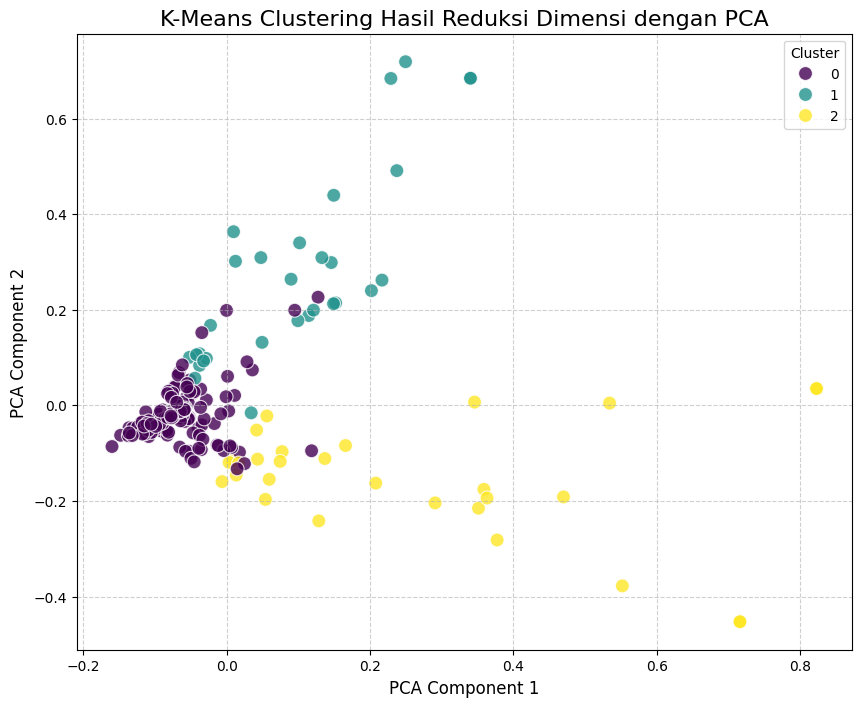

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


# Atur ukuran figure
plt.figure(figsize=(10, 8))

# Buat scatter plot
sns.scatterplot(
    x='pca_1',
    y='pca_2',
    hue='cluster_label',
    data=df,
    palette='viridis',
    s=100,
    alpha=0.8
)

# Tambahkan judul dan label sumbu
plt.title('K-Means Clustering Hasil Reduksi Dimensi dengan PCA', fontsize=16)
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)

# Tambahkan legenda
plt.legend(title='Cluster')

# Tampilkan plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Analisis Cluster

In [13]:
# Tampilkan contoh data dari Cluster 0
print("\n--- Contoh Data dari Cluster 0 ---")
display(df[df['cluster_label'] == 0]['DATA_normalized'].sample(min(10, len(df[df['cluster_label'] == 0]))).to_frame())


--- Contoh Data dari Cluster 0 ---


,DATA_normalized
217,kalian sok tau suka nyinyirin hidup rumah tang...
64,sukses selalu
158,angota dpr gamau denger omongan gimana
210,bawa agama mulu
183,perasaan bukan membuly safea justru psikolog m...
117,tidak bosen liat podcast episode benar lucu ba...
112,pertama liat jirayut pas lagi viral tangmonida...
132,bagaimana endingnya
129,jerayut titisan olga saputra
219,hari juta penonton lebih dhani efect


In [14]:
# Tampilkan contoh data dari Cluster 1
print("\n--- Contoh Data dari Cluster 1 ---")
display(df[df['cluster_label'] == 1]['DATA_normalized'].sample(min(10, len(df[df['cluster_label'] == 1]))).to_frame())


--- Contoh Data dari Cluster 1 ---


,DATA_normalized
17,balik lagi kesini kesekian kalinya
45,ded undang lagi dong halda jirayut
12,undang lagi
130,kesini lagi tanggal januari
139,nyasar lagi sini
90,bulan depan tanggal undang hanyut dong satu ta...
27,sekali halda berdua cow cakep coba
88,undang lagi abang hahaahaa sudah rewatch
111,ingin liat halda hamil
74,tolong dinundqng mereka dua lagi dong


In [15]:
# Tampilkan contoh data dari Cluster 2
print("\n--- Contoh Data dari Cluster 2 ---")
display(df[df['cluster_label'] == 2]['DATA_normalized'].sample(min(10, len(df[df['cluster_label'] == 2]))).to_frame())


--- Contoh Data dari Cluster 2 ---


,DATA_normalized
107,menonton berulang kali
142,menonton kali
104,suka banget episode tidak tahu sudah ngulang b...
28,tidak kerasa sudah tahu
80,sudah hampir setaun hanyut
166,otaknya sudah blacklist
106,tidak tau lagi sudah berapa kali menonton hald...
46,menonton ulang berkali tetap haha
120,sudah menonton
3,disaat halda sudah sadam masih disini
